# 🎬 Anime Dataset Analysis
### Exploring Trends, Ratings, and Popularity

## 📌 Project Overview
This project aims to analyze an anime dataset to uncover insights about ratings, popularity, and trends across different anime genres and characteristics.

## 🎯 Objectives
- Analyze the distribution of anime ratings
- Identify the most popular genres
- Explore the relationship between popularity and score
- Understand factors affecting anime ratings

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns
import plotly.io as pio
pio.renderers.default = 'notebook'


import warnings
warnings.filterwarnings("ignore")

sns.set_style('darkgrid')
sns.set_palette('muted')

In [11]:
url = "https://raw.githubusercontent.com/MSalah-Data/Python-Projects/refs/heads/main/Anime%20Analysis_Python%20Project/anime.csv"
df = pd.read_csv(url)
pd.set_option("display.max_columns", None )
df.head(5)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## 📊 Dataset Description
The dataset contains information about various anime titles, including:
- Name
- Genre
- Type
- Episodes
- Rating
- Members (popularity indicator)

## 🔍 Data Understanding

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [13]:
df.shape

(12294, 7)

In [14]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


### 📝 Observations:
- The dataset contains 12294 rows and 7 columns
- There are missing values in columns like 'rating' and 'genre'
- 'members' appears to represent popularity
- Some columns may require data type conversion

## 🧹 Data Cleaning

In [15]:
df[df['rating'] <0]

,anime_id,name,genre,type,episodes,rating,members


In [16]:
df['anime_id'].nunique()

12294

In [17]:
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)

In [18]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12017 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12017 non-null  int64  
 1   name      12017 non-null  object 
 2   genre     12017 non-null  object 
 3   type      12017 non-null  object 
 4   episodes  11830 non-null  float64
 5   rating    12017 non-null  float64
 6   members   12017 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 751.1+ KB


In [20]:
df.sample(10)

,anime_id,name,genre,type,episodes,rating,members
7531,30850,UFO Gakuen no Himitsu,"Sci-Fi, Space",Movie,1.0,5.34,1351
371,589,Ginga Nagareboshi Gin,"Action, Adventure, Drama, Shounen",TV,21.0,8.14,10575
6682,9393,T.P. Sakura: Time Paladin Sakura,"Action, Magic",OVA,2.0,6.00,2784
4612,11083,Nurarihyon no Mago: Sennen Makyou Recaps,"Action, Demons, Shounen, Supernatural",Special,2.0,6.68,7095
9605,28553,Momotarou no Hi Asobi Yameyou! Hi no Youjin,"Drama, Fantasy, Historical, Kids",OVA,1.0,6.00,39
10724,33099,Washimo 4th Season,"Comedy, Kids, School, Sci-Fi, Slice of Life",TV,NaN,5.60,64
6549,7953,Defend Love,"Adventure, Fantasy, Magic, Mecha, Music, Roman...",Music,1.0,6.06,1162
7619,30405,Ishindenshin Shiyou,"Kids, Music",Music,1.0,5.23,129
3345,11227,Rinne no Lagrange,"Action, Comedy, Mecha, Sci-Fi",TV,12.0,7.02,41486
6936,4104,Mini Moni the TV,Comedy,TV,15.0,5.84,273


In [21]:
df['name'] = df['name'].str.replace('&quot;', '"', regex=False)
df['name'] = df['name'].str.replace('&amp;', '&', regex=False)

In [22]:
df.sample(5)

,anime_id,name,genre,type,episodes,rating,members
5010,31608,Teekyuu 4 Specials,"Comedy, School, Shounen, Sports",Special,2.0,6.58,1977
1981,8423,Ookiku Furikabutte: Natsu no Scorebook,"Comedy, Sports",OVA,2.0,7.39,2167
9188,22615,Kero Kero Keroppi no Kero Kero House no Himitsu,"Fantasy, Kids",OVA,1.0,6.84,78
9925,28073,Papa Mama Bye Bye,"Historical, Kids",Movie,1.0,6.00,56
9966,29177,Persia no Komoriuta: Watashi no Hana,"Kids, Music",Music,1.0,3.63,87


### 📝 Cleaning Summary:
- Removed missing values from 'rating' column
- Converted 'episodes' to numeric format
- Dropped duplicate records
- Cleaned text columns for consistency

## 📊 Exploratory Data Analysis

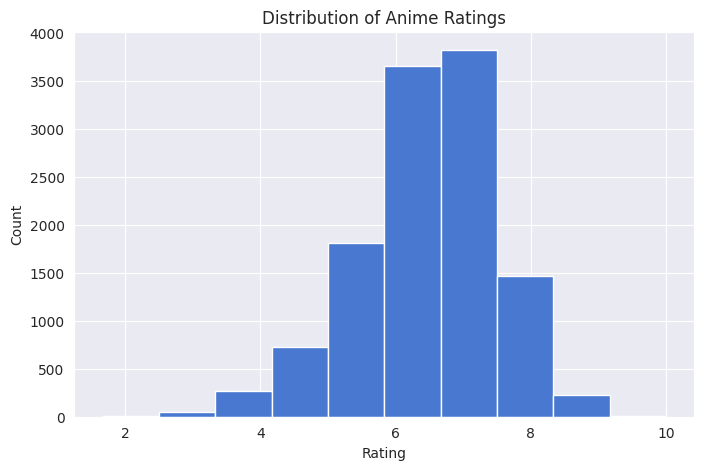

In [23]:
plt.figure(figsize=(8,5))
df['rating'].hist()
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

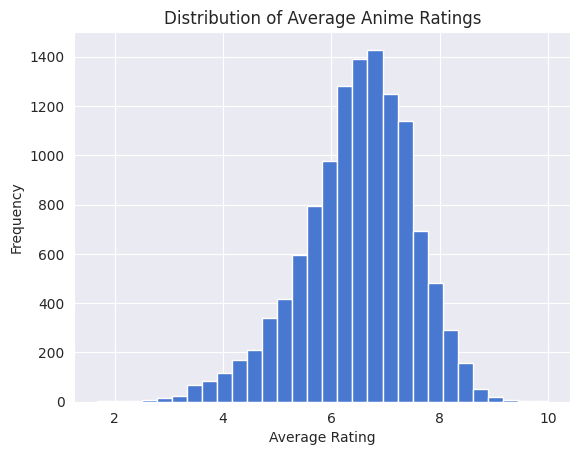

In [24]:
plt.figure()
plt.hist(df['rating'], bins=30)

plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Average Anime Ratings')

plt.show()

### 🔍 Insight:
Most anime ratings fall between 6 and 8, indicating that the majority of shows are good.

In [25]:
top10 = df.sort_values(by='members', ascending=False).head(10)
top10[['name', 'members']]

,name,members
40,Death Note,1013917
86,Shingeki no Kyojin,896229
804,Sword Art Online,893100
1,Fullmetal Alchemist: Brotherhood,793665
159,Angel Beats!,717796
19,Code Geass: Hangyaku no Lelouch,715151
841,Naruto,683297
3,Steins;Gate,673572
445,Mirai Nikki (TV),657190
131,Toradora!,633817


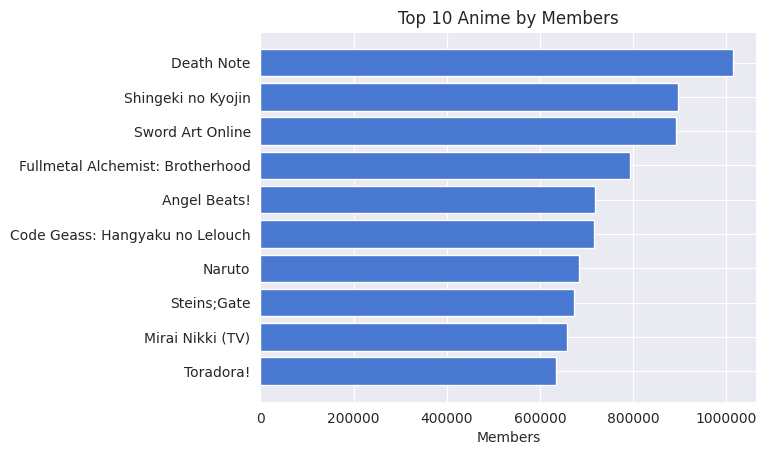

In [26]:
plt.barh(top10['name'], top10['members'])
plt.gca().invert_yaxis()
plt.xlabel('Members')
plt.title('Top 10 Anime by Members')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

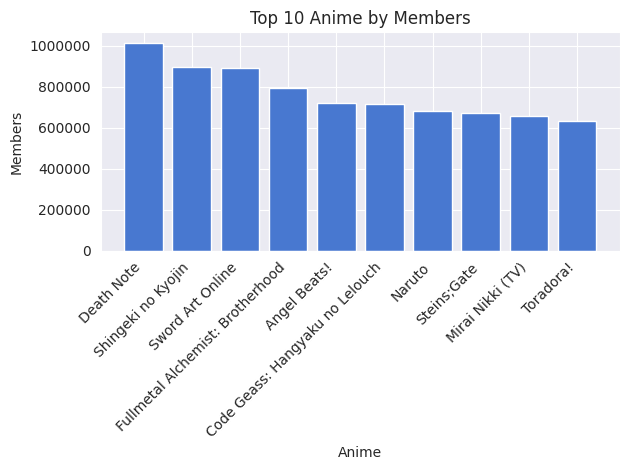

In [27]:
plt.figure()
plt.bar(top10['name'], top10['members'])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Anime')
plt.ylabel('Members')
plt.title('Top 10 Anime by Members')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [28]:
type_counts = df['type'].value_counts()

type_counts

,count
type,
TV,3668
OVA,3284
Movie,2259
Special,1670
ONA,648
Music,488


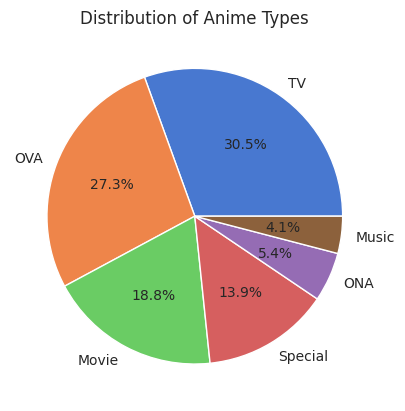

In [29]:
plt.figure()
type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distribution of Anime Types')
plt.show()

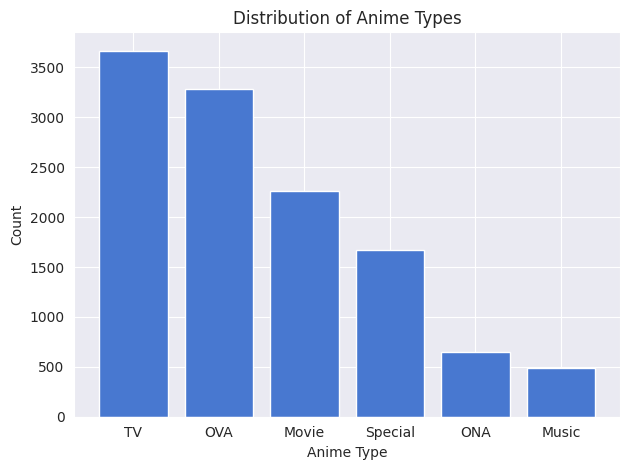

In [30]:
plt.figure()
plt.bar(type_counts.index, type_counts.values)

plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.title('Distribution of Anime Types')

plt.tight_layout()
plt.show()

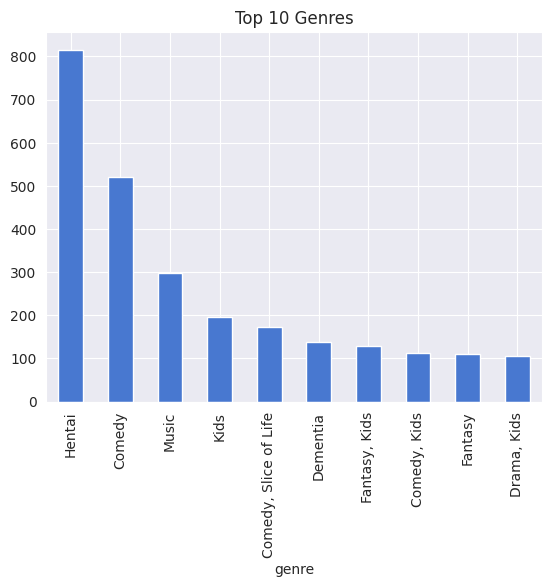

In [31]:
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.show()

### 🔍 Insight:
Hentai and Comedy are among the most frequent genres, showing strong audience preference for entertainment-focused content.

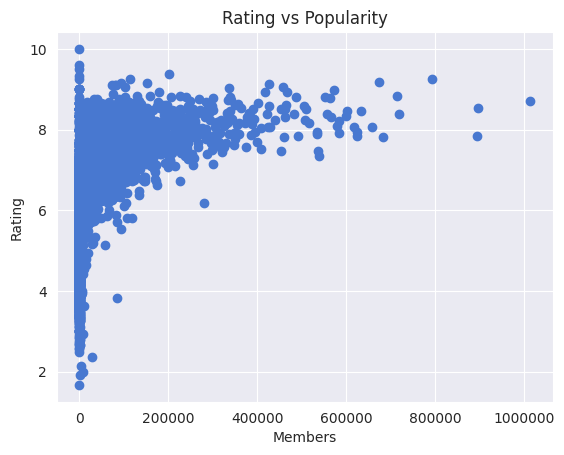

In [33]:
plt.scatter(df['members'], df['rating'])

plt.title("Rating vs Popularity")
plt.xlabel("Members")
plt.ylabel("Rating")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

### 🔍 Insight:
There is no strong direct relationship between popularity and rating, indicating that highly popular anime are not always highly rated.

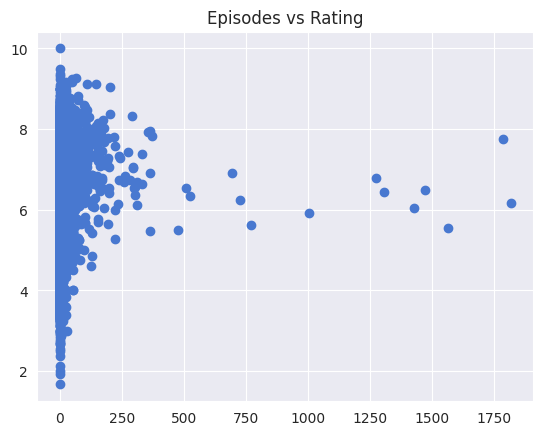

In [34]:
plt.scatter(df['episodes'], df['rating'])
plt.title("Episodes vs Rating")
plt.show()

### 🔍 Insight:
Longer anime do not necessarily achieve higher ratings, suggesting that quality matters more than length.

## 🧾 Conclusion

This analysis explored key patterns in the anime dataset, focusing on ratings, popularity, and content characteristics.

The findings show that:
- Most anime have ratings between 6 and 8
- Popularity does not always reflect quality
- Certain genres dominate the dataset
- The number of episodes has limited impact on ratings

Overall, the project highlights how data analysis can uncover meaningful insights that are not obvious at first glance.

Future work could include building a predictive model to estimate anime ratings based on features like genre, episodes, and popularity.

## 🚀 Next Steps

- Build a machine learning model to predict ratings  
- Perform deeper genre-based analysis  
- Explore time trends if data is available  